# 5. Phase covariance

**Note:**
- The numbers $a_1$, $a_2$ come from adjusting the data to the function $\text{Airy}_1(x)$ at two points: $(0, \text{Airy}_1(0))$ and $(0.5, \text{Airy}_1(0.5))$. 
- That must be done for each time instant, therefore $a_1(t)$ and $a_2(t)$.
- For columnar noise the data should not collapse to the $\text{Airy}_1$ function, only crossing it at the enforced points $0,0.5$. Instead it should match Larkin's one (this fact was surprising since the PDF is that of KPZ, as is $\text{Airy}_1$).
- For Larkin's function, there is no closed form solution (or at least, there is no "nicely looking" one). Instead, as with $\text{Airy}_1$, it's better to have tables of values.
- The same ideas (computing $a_1, a_2$ adjusting two points) can be used for Larkin's function, but: in this case there should be no time dependence. Also, there is a formula () 

In [1]:
import numpy as np
import pandas as pd
import os

from surface_functions import compute_phase_covariance

In [2]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

## Dataframe computations

In [3]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Simulations/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        hprodh_average_list = []  # used to compute per-sim \overline{h(x,t)h(x+r,t)}
        h_average_list = []  # used to compute per-sim height \overline{h(x,t)}

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            hprodh_average, h_average = compute_phase_covariance(phases)

            hprodh_average_list.append(hprodh_average)
            h_average_list.append(h_average)

        # Avoid chained-assignment issues
        df = df.copy()
        df["hprodh_average"] = hprodh_average_list
        df["h_average"] = h_average_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE PHASE-COVARIANCE PER (K, L, T) ##
        # group by K, L, T and compute mean phase-covariance for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            hprodh_average_arrays = [np.asarray(r, dtype=float) for r in group["hprodh_average"]]
            h_average_arrays = [np.asarray(r, dtype=float) for r in group["h_average"]]

            # Term 1: < overline{φ(x, t) φ(x + r, t)} >
            term1 = np.mean(np.stack(hprodh_average_arrays, axis=0), axis=0)

            # Term 2: ( < overline{φ}(x, t) > )^2
            # Note: h_average_arrays has shape (M, Nt), so we mean over axis 0 to get (Nt,)
            term2 = np.mean(np.stack(h_average_arrays, axis=0), axis=0)**2

            # We need to broadcast term2 (Nt,) to match term1 (Nt, N)
            # Since term2 varies only with time, we subtract it from every 'r' column
            mean_phasecovariance = term1 - term2[:, np.newaxis]

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_phasecovariance": mean_phasecovariance,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [4]:
avg_df_path = "Simulations/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_phasecovariance"] = new_avg["mean_phasecovariance"]

avg_df.to_pickle(avg_df_path)

In [5]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight,mean_structurefactor,mean_phasecovariance
avg_id,,,,,,,,,,,,,
TimeDep_delta0_L250_K0.01_T20000_M500,TimeDep,0.000000,0,0.01,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.09916611074910535, 0.12446928020870274...","[0.0, 0.09926446968727078, 0.12458840997396499...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L125_K1.0_T20000_M2563,TimeDep,0.000000,0,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",2563,20000,"[0.0, 0.06168110958657668, 0.06939519822266577...","[0.0, 0.061875751647655915, 0.0696491476573002...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L250_K1.0_T20000_M2038,TimeDep,0.000000,0,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",2038,20000,"[0.0, 0.061965631959170625, 0.0700407179442727...","[0.0, 0.062059291870438106, 0.0701756752784753...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L500_K1.0_T20000_M1795,TimeDep,0.000000,0,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1795,20000,"[0.0, 0.0621714227145654, 0.07011549882291095,...","[0.0, 0.06221984053743999, 0.07018256920069725...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L1000_K1.0_T20000_M3448,TimeDep,0.000000,0,1.00,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3448,20000,"[0.0, 0.06239254779952913, 0.07052040800441967...","[0.0, 0.0624165838743001, 0.07055298550407245,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L250_K0.01_T20000_M500,TimeDep,1.373401,atan5,0.01,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.10017369796474682, 0.12628080395076277...","[0.0, 0.10027197517138416, 0.12640602800694029...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L125_K1.0_T20000_M2573,TimeDep,1.373401,atan5,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",2573,20000,"[0.0, 0.08494848921438407, 0.09996033569969529...","[0.0, 0.08513315588534826, 0.10019966225840135...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L250_K1.0_T20000_M2084,TimeDep,1.373401,atan5,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",2084,20000,"[0.0, 0.0853817935442105, 0.10083697526055763,...","[0.0, 0.0854676581318955, 0.1009525728111536, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K1.0_T20000_M1738,TimeDep,1.373401,atan5,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1738,20000,"[0.0, 0.08563020075369611, 0.10095360330656193...","[0.0, 0.08567629915216575, 0.10101165939873313...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [7]:
avg_df.loc["TimeDep_delta0_L250_K0.01_T20000_M500", "mean_phasecovariance"]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 9.89092043e-03,  1.14349219e-04,  6.08510352e-06, ...,
        -1.56171847e-05,  6.08510352e-06,  1.14349219e-04],
       [ 1.55814295e-02,  2.87211650e-04, -3.36551744e-06, ...,
         8.97281964e-06, -3.36551744e-06,  2.87211650e-04],
       ...,
       [ 2.01104142e+01,  1.09100712e+01,  6.46932377e+00, ...,
         3.96523636e+00,  6.46932377e+00,  1.09100712e+01],
       [ 3.24697266e+01,  1.74629508e+01,  1.01839096e+01, ...,
         6.09218326e+00,  1.01839096e+01,  1.74629508e+01],
       [ 5.19893618e+01,  2.77790455e+01,  1.61163199e+01, ...,
         9.62363232e+00,  1.61163199e+01,  2.77790455e+01]],
      shape=(23, 250))

## Inspection of the computed quantities

In [8]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

%load_ext autoreload
%autoreload 2

from plotting_helpers_evolution import plot_phasecovariance_evolution
from plotting_helpers_collapse import plot_phasecovariance_collapse

In [9]:
avg_df_path = "Simulations/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

L = 1000
T = 20000
Ks = [1, 40]

In [10]:
markerdict = {500: "o", 250: "x", 125: "^", 1000: "s"}

In [11]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/30, "KPZ": 1/4}, "Columnar": {"EW": 1/800, "KPZ": 1/20}}

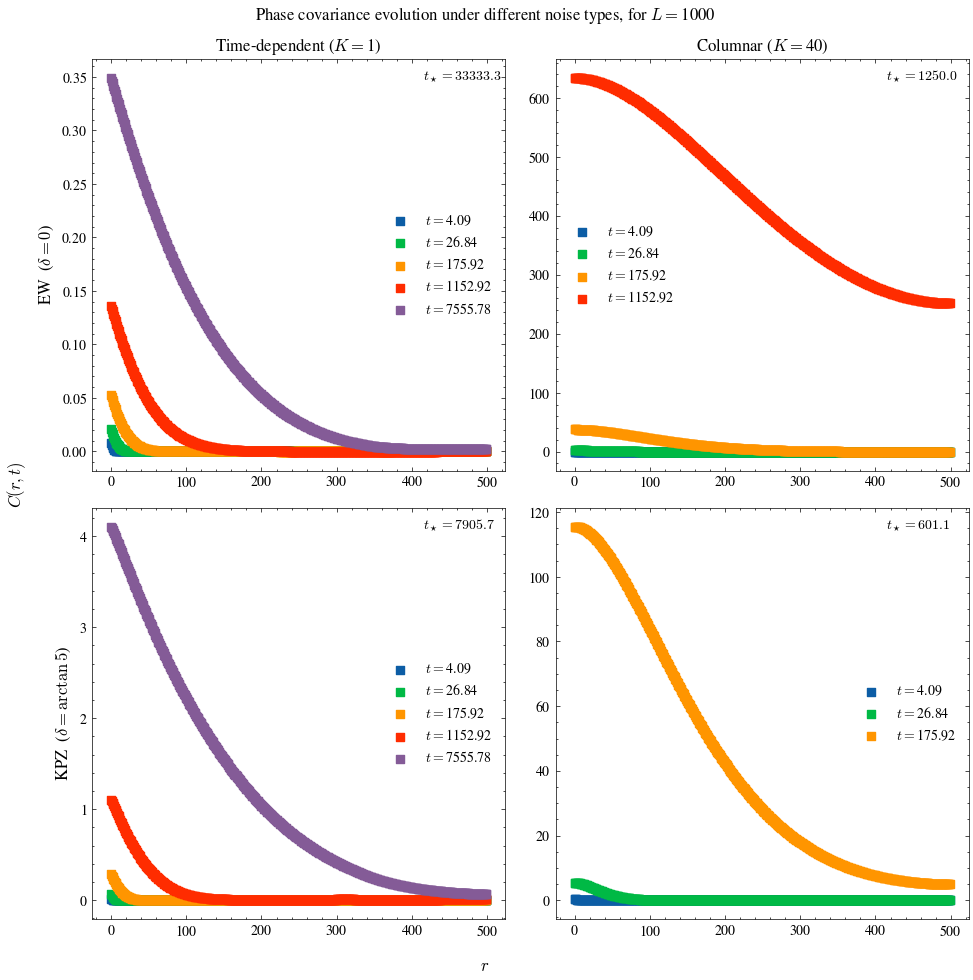

In [12]:
plot_phasecovariance_evolution(avg_df, L, T, tx, Ks=[1,40])

### Family-Vicsek collapse of the phase covariance

We need constants $a_1$, $a_2$, which are fit assuming the functional form.

/mnt/datos/gonzalo/Projects/RoughKuramoto/plotting_helpers_collapse.py:340: IntegrationWarning: The maximum number of subdivisions (300) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(lambda kappa: np.cos(2*np.pi*kappa*x) * g(kappa), 0.0, np.inf,


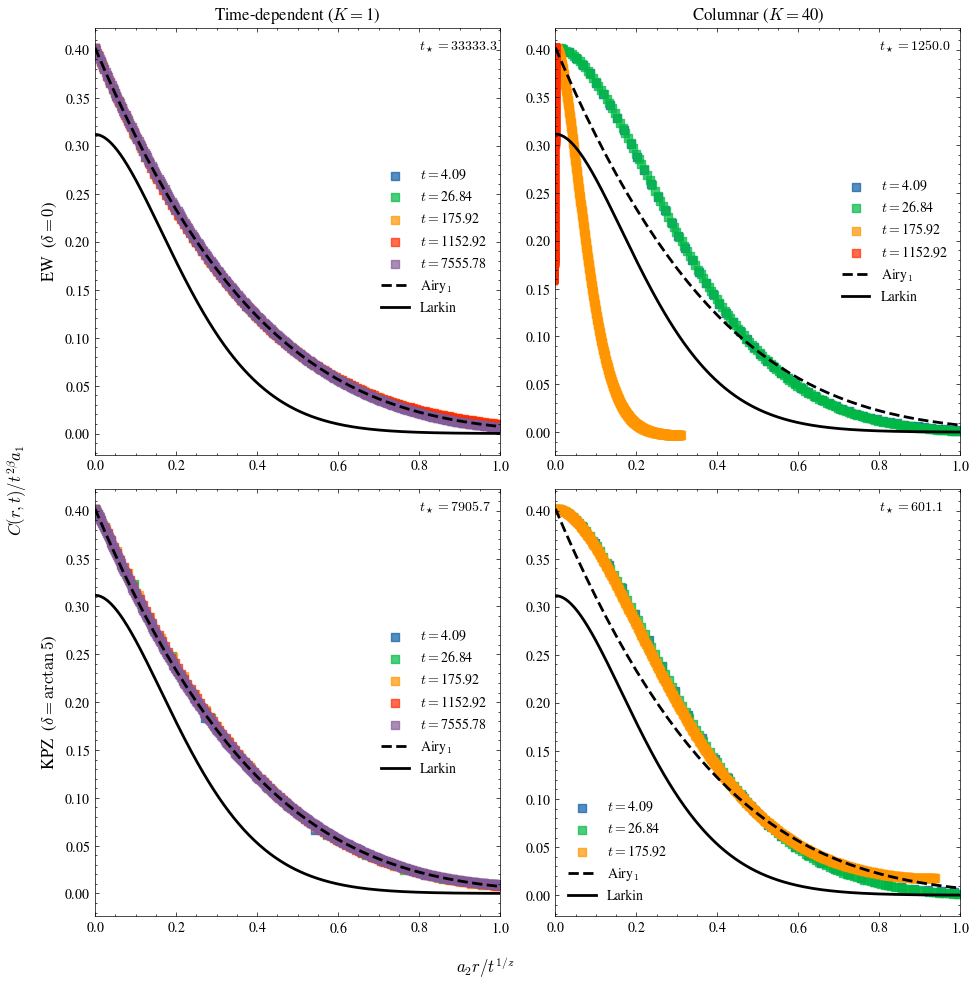

In [13]:
a_1_dict, a_2_dict = plot_phasecovariance_collapse(avg_df, L, T, tx, Ks=[1,40])

In [14]:
a_1_dict

{'TimeDep': {'0': [np.float64(0.00990409205289433),
   np.float64(0.00994295096315149),
   np.float64(0.009929063430662978),
   np.float64(0.009958708536708697),
   np.float64(0.009988058480825813)],
  'atan5': [np.float64(0.018412391557687743),
   np.float64(0.018938431467077427),
   np.float64(0.022485995472922876),
   np.float64(0.025003545693462043),
   np.float64(0.026522285135335884)]},
 'Columnar': {'0': [np.float64(0.0409357360714839),
   np.float64(0.04058378973566585),
   np.float64(0.04017640698865791),
   np.float64(0.04027895432825606)],
  'atan5': [np.float64(0.08092596431516703),
   np.float64(0.07660394381898496),
   np.float64(0.08421053037097044)]}}

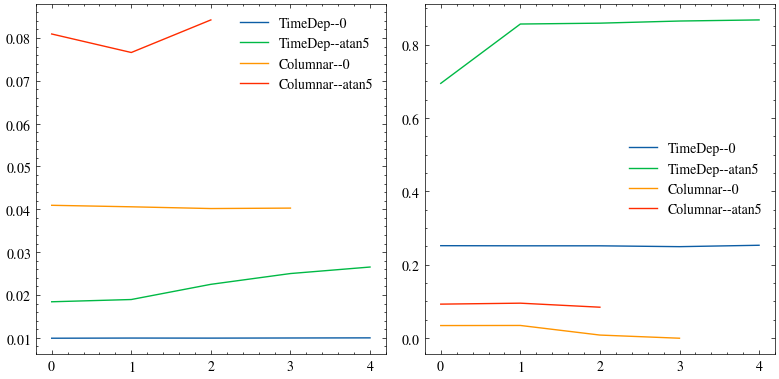

In [15]:
fig, ax = plt.subplots(1,2, figsize=(8,4))

for key, val in a_1_dict.items():
    
    for key_2, val_2 in val.items():
        # print(key, val, key_2, val_2)
        ax[0].plot(val_2, label=key+"--"+key_2)
        ax[1].plot(a_2_dict[key][key_2], label=key+"--"+key_2)

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()

### Airy and Larkin

In [16]:
from scipy.integrate import quad

def larkin_inv_ft(x, eps=1e-6, rtol=1e-10, atol=1e-12, limit=300):
    """
    Computes  F^{-1}[ ((1 - e^{-k^2})^2 / k^4) ](x)
    using the convention:
        F^{-1}[g](x) = (1/2π)∫_{-∞}^{∞} e^{ikx} g(k) dk
                     = (1/π) ∫_0^∞ cos(kx) g(k) dk   (g even)

    Parameters
    ----------
    x : float
        Evaluation point.
    eps : float
        Threshold for using the small-k series to avoid 0/0.
    rtol, atol : float
        quad tolerances.
    limit : int
        quad subinterval limit.

    Returns
    -------
    float
        Value of the inverse transform at x.
    """

    x = float(x)

    # small-k series: ((1-e^{-k^2})^2 / k^4) = 1 - k^2 + (7/12)k^4 + O(k^6)
    def g(k):
        k = float(k)
        ak = abs(k)
        if ak < eps:
            k2 = k*k
            return 1.0 - k2 + (7.0/12.0)*k2*k2
        return (1.0 - np.exp(-k*k))**2 / (k**4)

    def integrand(k):
        return np.cos(2 * np.pi * k * x) * g(k)

    val, err = quad(integrand, 0.0, np.inf, epsrel=rtol, epsabs=atol, limit=limit)
    return val / np.pi


In [17]:
def larkin_inv_ft_2(x, eps=1e-6, rtol=1e-10, atol=1e-12, limit=300):
    """
    Computes  F^{-1}[ ((1 - e^{-k^2})^2 / k^4) ](x)
    using the convention:
        F^{-1}[g](x) = (1/2π)∫_{-∞}^{∞} e^{ikx} g(k) dk
                     = (1/π) ∫_0^∞ cos(kx) g(k) dk   (g even)

    Parameters
    ----------
    x : float
        Evaluation point.
    eps : float
        Threshold for using the small-k series to avoid 0/0.
    rtol, atol : float
        quad tolerances.
    limit : int
        quad subinterval limit.

    Returns
    -------
    float
        Value of the inverse transform at x.
    """

    def g(kappa):
        ak = abs(kappa)
        if ak < eps:
            k2 = kappa*kappa
            return 1.0 - k2 + (7.0/12.0)*k2*k2  # series at κ=0
        return (1.0 - np.exp(-kappa*kappa))**2 / (kappa**4)

    val, _ = quad(lambda kappa: np.cos(2*np.pi*kappa*x) * g(kappa), 0.0, np.inf,
                  epsrel=rtol, epsabs=atol, limit=limit)
    return val / np.pi   # (1/2π) over R -> (1/π) cosine integral


/tmp/ipykernel_2160416/99166540.py:32: IntegrationWarning: The maximum number of subdivisions (300) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(lambda kappa: np.cos(2*np.pi*kappa*x) * g(kappa), 0.0, np.inf,


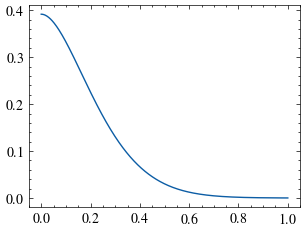

In [18]:
nu = 50
ti = 500
sigma=0.1

# plt.plot(np.linspace(0, 1, 400), 4*np.pi*(ti**(3/2)) * np.array([larkin_inv_ft(rr/np.sqrt(nu*ti)) for rr in np.linspace(0, 1, 400)]) / nu**(1/2)) 
plt.plot(np.linspace(0, 1, 400), 4*np.pi*sigma * np.array([larkin_inv_ft_2(rr) for rr in np.linspace(0, 1, 400)])) 

In [19]:
def C_phi_larkin(ell, t, nu, sigma, inv_ft=larkin_inv_ft):
    """
    C_phi(ell,t) = (4π σ t^{3/2} / ν^{1/2}) * inv_ft( ell / sqrt(ν t) )
    """
    x = ell / np.sqrt(nu * t)
    return (4.0 * np.pi * sigma * (t**1.5) / np.sqrt(nu)) * inv_ft(x)

/tmp/ipykernel_2160416/1072990692.py:41: IntegrationWarning: The maximum number of subdivisions (300) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, err = quad(integrand, 0.0, np.inf, epsrel=rtol, epsabs=atol, limit=limit)


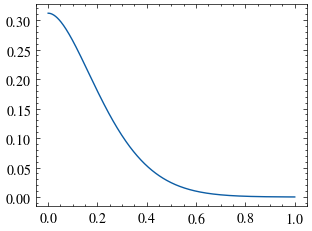

In [20]:
plt.plot(np.linspace(0, 1, 400), [larkin_inv_ft(rr) for rr in np.linspace(0, 1, 400)]) 

In [21]:
with open("airy_1_values.txt", 'r') as f:
    Airy_1 = {float(line.split(" ")[0]): float(line.split(" ")[1]) for line in f.readlines()}

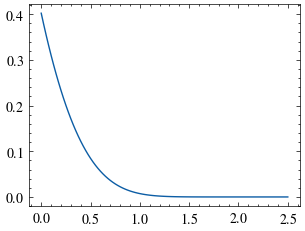

In [22]:
plt.plot(list(Airy_1.keys()), list(Airy_1.values()))

In [23]:
(0, Airy_1[0]), (0.5, Airy_1[0.5])

((0, 0.401945258645), (0.5, 0.084419174))